In [1]:
from dotenv import load_dotenv
import os
from daytona import Daytona, DaytonaConfig
from daytona import FileDownloadRequest
import base64
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
load_dotenv()

config = DaytonaConfig(api_key=os.getenv("DAYTONA_API_KEY"))
daytona = Daytona(config)
sandbox = daytona.create()

In [2]:
from langchain_groq import ChatGroq
model = ChatGroq(model="openai/gpt-oss-120b")
image_model = ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

c:\Users\Prasanna\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def upload_csv(sandbox, local_path: str, remote_path: str = "data.csv"):
    """
    Upload a local CSV file into Daytona sandbox.
    """
    with open(local_path, "rb") as f:
        content = f.read()

    sandbox.fs.upload_file(content, remote_path)

In [4]:
upload_csv(sandbox=sandbox,local_path="hair_eye_color_CSV.csv")

In [5]:
def run_python_code(sandbox, code: str) -> str:
    """
    Execute Python code inside Daytona sandbox.
    Returns stdout if successful.
    """
    response = sandbox.process.code_run(code)

    if response.exit_code != 0:
        raise RuntimeError(f"Execution failed: {response.result}")

    return response.result

In [6]:
def write_file_tool(remote_path: str, content: str | bytes):
    """
    Write content to a file inside Daytona sandbox.
    Overwrites if file exists.
    """

    if isinstance(content, str):
        content = content.encode("utf-8")

    sandbox.fs.upload_file(content, remote_path)

    return f"File written to {remote_path}"

In [7]:
def read_file_tool(remote_path: str) -> str:
    """
    Read file from Daytona sandbox.
    Returns text content.
    """

    content = sandbox.fs.download_file(remote_path)
    return content.decode("utf-8")

In [8]:
from typing import TypedDict, Literal, Annotated, List
from operator import add

In [9]:
class Mystate(TypedDict):
    summary : Annotated[List[str], add]
    last_step : str
    final_analysis : str


In [30]:
def csv_summary_node(state) -> Mystate:
    csv_path = "data.csv"
    summary_path = "summary.txt"

    code = f"""
import pandas as pd
import os

df = pd.read_csv("{csv_path}")

with open("{summary_path}", "w") as f:
    f.write("CSV SUMMARY REPORT\\n")
    f.write("="*50 + "\\n\\n")
    
    f.write(f"Shape: {{df.shape}}\\n\\n")
    
    f.write("Columns:\\n")
    for col in df.columns:
        f.write(f" - {{col}}\\n")
    f.write("\\n")
    
    f.write("Data Types:\\n")
    for col, dtype in df.dtypes.items():
        f.write(f" - {{col}}: {{dtype}}\\n")
    f.write("\\n")
    
    f.write("Missing Values:\\n")
    for col, count in df.isnull().sum().items():
        f.write(f" - {{col}}: {{count}}\\n")
    f.write("\\n")
    
    f.write("Statistical Summary:\\n")
    f.write(df.describe(include='all').to_string())

print("SUMMARY_CREATED")
"""

    response = sandbox.process.code_run(code)

    if response.exit_code != 0:
        raise RuntimeError(response.result)
    
    summary_path ="summary.txt"

    content = sandbox.fs.download_file(summary_path)
    state["summary"] = [content.decode("utf-8")]

    return state

In [23]:

class NullCode(BaseModel):
    code: str = Field(
        description="Valid executable Python code that removes null values from data.csv and overwrites data.csv"
    )

null_parser = PydanticOutputParser(pydantic_object=NullCode)


null_prompt = PromptTemplate(
    template="""
        You are a professional data scientist.

        Your task:
        - Generate ONLY executable Python code.
        - The code must:
            1. Read 'data.csv'
            2. Remove null values intelligently based on the summary provided
            3. Overwrite the cleaned dataframe back into 'data.csv'
            4. Print "NULL_VALUES_REMOVED" at the end

        Rules:
        - Do NOT add explanations.
        - Do NOT wrap code in markdown.
        - Output must strictly follow the format instructions.
        - 

        Summary of dataset:
        {summary}

        {format_instructions}
""",
    input_variables=["summary"],
    partial_variables={
        "format_instructions": null_parser.get_format_instructions()
    }
)

model_null = null_prompt | model | null_parser

In [24]:
def remove_null(state:Mystate) -> Mystate:
    summary = state['summary']
    code = model_null.invoke({'summary':summary})
    generated_code = code.code

    generated_code = generated_code.encode().decode("unicode_escape")
    response = sandbox.process.code_run(generated_code)

    if response.exit_code != 0:
        raise RuntimeError(response.result)
    state['last_step'] = "removed null values"
    return state
    

In [25]:
class EncodeCode(BaseModel):
    code: str = Field(
        description="Executable Python code that encodes categorical columns in data.csv, overwrites data.csv, and writes operation summary to summary.txt"
    )

encode_parser = PydanticOutputParser(pydantic_object=EncodeCode)


encode_prompt = PromptTemplate(
    template="""
        You are a professional data scientist.

        Generate ONLY raw executable Python code.

        Task:
        1. Read 'data.csv'
        2. Detect categorical columns automatically
        3. Encode categorical columns using Label Encoding
        4. Store encoding mappings in summary.txt
        5. Overwrite updated dataframe to data.csv
        6. Print "ENCODING_COMPLETED" at the end

        Requirements:
        - Use pandas and sklearn.preprocessing.LabelEncoder
        - Store encoding mappings like:
        {{
            "encoded_columns": [...],
            "mappings": {{
                "column_name": {{"category": encoded_value}}
            }}
        }}
        - Overwrite summary.txt
        - Do NOT escape newline characters
        - Do NOT wrap code in markdown
        - Output strictly valid Python


        Dataset Summary:
        {summary}

        {format_instructions}
        """,
    input_variables=["summary"],
    partial_variables={
        "format_instructions": encode_parser.get_format_instructions()
    }
)

model_encode = encode_prompt | model | encode_parser

In [26]:
def encode_cat(state:Mystate) -> Mystate:
    summary = state['summary']
    code = model_encode.invoke({'summary':summary})
    generated_code = code.code

    generated_code = generated_code.encode().decode("unicode_escape")
    response = sandbox.process.code_run(generated_code)

    if response.exit_code != 0:
        raise RuntimeError(response.result)
    state['last_step'] = "encoded columns"
    summary_path ="summary.txt"
    content = sandbox.fs.download_file(summary_path)
    state["summary"] = [content.decode("utf-8")]
    return state
    

In [15]:
class PlotCode(BaseModel):
    code: str = Field(
        description="Executable Python code that generates multiple plots using matplotlib and seaborn and saves them in a folder named 'visualizations'"
    )

plot_parser = PydanticOutputParser(pydantic_object=PlotCode)

plot_prompt = PromptTemplate(
    template="""
        You are a professional data scientist.

        Generate executable Python code.

        Task:
        1. Read 'data.csv'
        2. Create multiple plots using matplotlib and seaborn
        3. Save all plots inside a folder named 'visualizations'

        Requirements:
        - Use matplotlib.pyplot as plt
        - Use seaborn as sns
        - Create the folder if it does not exist
        - Save each plot using plt.savefig()
        - Close each figure using plt.close()
        - Do NOT wrap code in markdown
        - Output strictly valid JSON following the format instructions

        Dataset Summary:
        {summary}

        {format_instructions}
        """,
    input_variables=["summary"],
    partial_variables={
        "format_instructions": plot_parser.get_format_instructions()
    }
)

model_plot = plot_prompt | model | plot_parser

In [27]:
def create_plots(state:Mystate) -> Mystate:
    summary = state['summary']
    code = model_plot.invoke({'summary':summary})
    generated_code = code.code

    generated_code = generated_code.encode().decode("unicode_escape")
    response = sandbox.process.code_run(generated_code)

    if response.exit_code != 0:
        raise RuntimeError(response.result)
    state['last_step'] = "created graphs"

    return state
    

In [17]:
def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

In [18]:
def final_analysis(state:Mystate) -> Mystate:

    files = sandbox.fs.list_files("visualizations")
    plot_files = []

    for file in files:
        if not file.is_dir:  
            plot_files.append(f"visualizations/{file.name}")

    requests = [
    FileDownloadRequest(source=path)
    for path in plot_files]

    results = sandbox.fs.download_files(requests)

    os.makedirs("downloaded_plots", exist_ok=True)

    for result in results:
        if result.error:
            print(f"Error: {result.error}")
        elif result.result:
            filename = os.path.basename(result.source)
            local_path = os.path.join("downloaded_plots", filename)

            with open(local_path, "wb") as f:
                f.write(result.result)

            print(f"Saved: {local_path}") 

    
    folder_path = "downloaded_plots"
    image_messages = []
    image_count = 1

    for file in os.listdir(folder_path):
        if image_count > 5:
            break
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(folder_path, file)
            base64_img = encode_image(full_path)

            image_messages.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{base64_img}"
                }
            })
            image_count += 1


    summ = state['summary']
    analysis_prompt = f"""
        You are a senior data analyst and statistical expert.

        Your task:
        Provide a detailed, structured analysis of the given graphs and plots.

        Requirements:

        1. Structure your analysis into clear sections:
        - Overview of dataset
        - Key trends observed
        - Patterns and distributions
        - Relationships between variables
        - Outliers or anomalies
        - Impact of preprocessing
        - Business or practical insights
        - Recommendations

        2. Use statistical reasoning wherever possible.
        3. Explain why patterns might exist.
        4. Comment on correlations, skewness, clusters, and variance if visible.
        5. Discuss how preprocessing steps influenced the results.
        5. Give proper output format 

        Preprocessing Summary:
        {summ} """

            
    message = HumanMessage(
        content=[
            {"type": "text", "text":analysis_prompt},
            *image_messages
        ]
    )

    response = image_model.invoke([message])

    with open("output.md", "w") as file:
        file.write(response.content)
    return {
        "final_analysis": response.content
    }
              

In [31]:
graph = StateGraph(Mystate)
graph.add_node("summary",csv_summary_node)
graph.add_node("remove_null",remove_null)
graph.add_node("encode_cat",encode_cat)
graph.add_node("create_plots",create_plots)
graph.add_node("final_analysis",final_analysis)

graph.add_edge(START,"summary")
graph.add_edge("summary","remove_null")
graph.add_edge("remove_null","encode_cat")
graph.add_edge("encode_cat","create_plots")
graph.add_edge("create_plots","final_analysis")
graph.add_edge("final_analysis",END)

workflow = graph.compile()

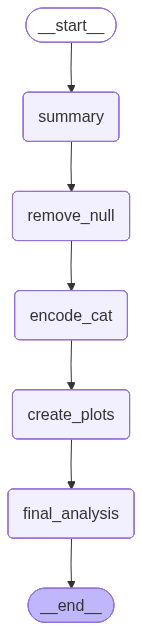

In [20]:
workflow

In [32]:
res = workflow.invoke({"last_step":"start"})

Saved: downloaded_plots\eye_color_count.png
Saved: downloaded_plots\hair_color_count.png
Saved: downloaded_plots\person_no_by_eye_color.png
Saved: downloaded_plots\person_no_by_hair_color.png


In [33]:
res['summary']

['CSV SUMMARY REPORT\n==================================================\n\nShape: (20, 3)\n\nColumns:\n - Person No.\n - Hair Color\n - Eye Color\n\nData Types:\n - Person No.: int64\n - Hair Color: object\n - Eye Color: object\n\nMissing Values:\n - Person No.: 0\n - Hair Color: 0\n - Eye Color: 0\n\nStatistical Summary:\n        Person No. Hair Color Eye Color\ncount     20.00000         20        20\nunique         NaN          4         4\ntop            NaN      Brown     Brown\nfreq           NaN          7        10\nmean      10.50000        NaN       NaN\nstd        5.91608        NaN       NaN\nmin        1.00000        NaN       NaN\n25%        5.75000        NaN       NaN\n50%       10.50000        NaN       NaN\n75%       15.25000        NaN       NaN\nmax       20.00000        NaN       NaN',
 'CSV SUMMARY REPORT\n==================================================\n\nShape: (20, 3)\n\nColumns:\n - Person No.\n - Hair Color\n - Eye Color\n\nData Types:\n - Person No.: int

In [34]:
res['final_analysis']

'## **Detailed Analysis of Graphs and Plots**\n\n### **Overview of Dataset**\n\nThe dataset consists of 20 entries across three columns: **Person No.**, **Hair Color**, and **Eye Color**. The data types are:\n\n- **Person No.**: `int64`\n- **Hair Color**: `object`\n- **Eye Color**: `object`\n\nThere are no missing values in any of the columns. The **Person No.** ranges from 1 to 20, with a mean of 10.5 and a standard deviation of 5.92. Both **Hair Color** and **Eye Color** have 4 unique values each, with **Brown** being the most frequent for both.\n\n### **Key Trends Observed**\n\n1. **Eye Color Distribution**:\n   - **Brown (encoded as 2)** is the most common eye color, with a count of 10.\n   - **Blue (encoded as 1)** is the second most common, with a count of 5.\n   - **Green (encoded as 3)** and **Black (encoded as 0)** are less common, with counts of 2 and 3, respectively.\n\n2. **Hair Color Distribution**:\n   - **Brown (encoded as 2)** is the most common hair color, with a count